In [ ]:
# importing libraries

from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import shutil

In [ ]:
DATA = Path("../raw/plantvillage/color") 

#### number of images

In [ ]:
folders = [f for f in DATA.iterdir() if f.is_dir()]
print(f"Found {len(folders)} folders (classes):")
print([f.name for f in folders[:10]])  

filepaths = []
labels = []

for folder in folders:
    for img_path in folder.glob("*"):
        if img_path.is_file():
            filepaths.append(str(img_path))
            labels.append(folder.name)

print(f" Total images: {len(filepaths)}")
print(f" Total labels: {len(labels)}")

Found 38 folders (classes):
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']
 Total images: 54305
 Total labels: 54305


#### creating dataframe

In [ ]:
data_df = pd.Series(filepaths, name='filepaths')
label_df = pd.Series(labels, name='labels')
data = pd.concat([data_df, label_df], axis=1)

In [ ]:
# number of images per class

counts = data.labels.value_counts()
counts

labels
Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___Late_blight                                  1909
Squash___Powdery_mildew                               1835
Tomato___Septoria_leaf_spot                           1771
Tomato___Spider_mites Two-spotted_spider_mite         1676
Apple___healthy                                       1645
Tomato___healthy                                      1591
Blueberry___healthy                                   1502
Pepper,_bell___healthy                                1478
Tomato___Target_Spot                                  1404
Grape___Esca_(Black_Measles)                          1383
Corn_(maize)___Common_rust_                           1192
Grape___Black_rot                                

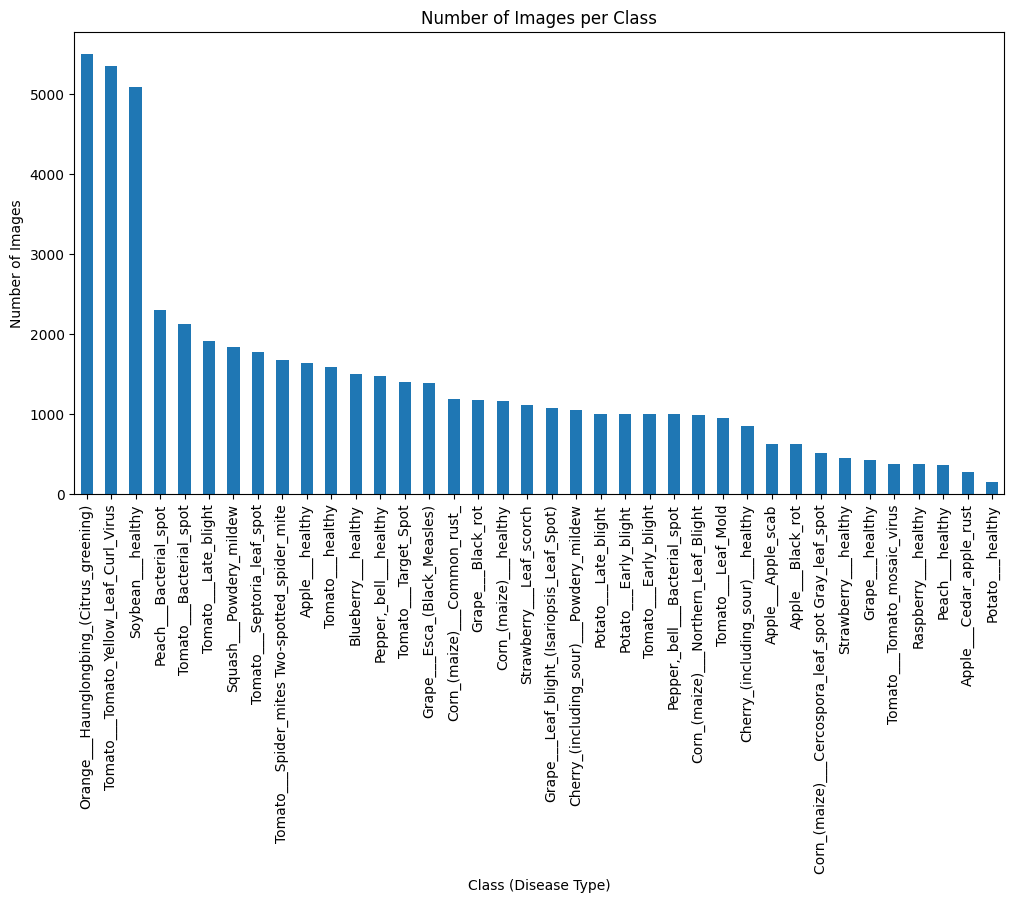

In [ ]:
plt.figure(figsize=(12, 6))
counts.plot(kind='bar')
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)

plt.show()

#### display some samples

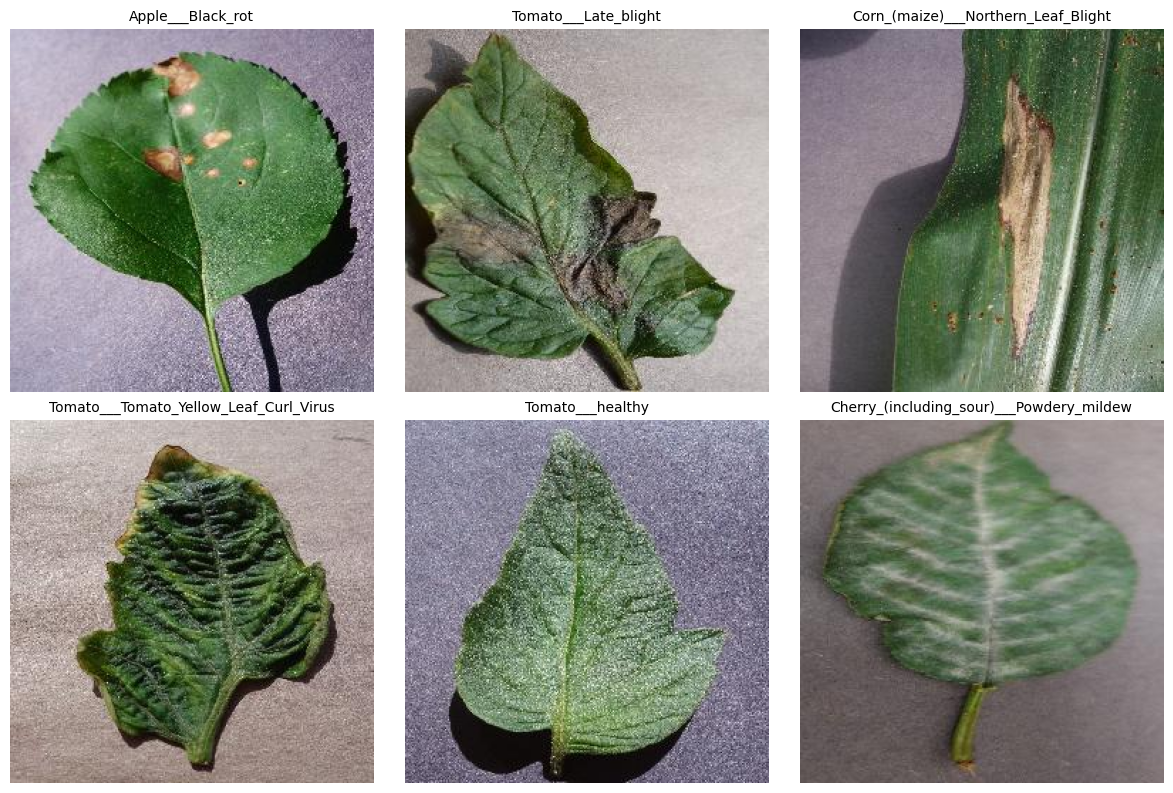

In [43]:
plt.figure(figsize=(12, 8))

for i in range(6): 
    plt.subplot(2, 3, i + 1)
    
    
    rand_idx = np.random.randint(0, len(data))
    img_path = data.iloc[rand_idx]['filepaths']
    label = data.iloc[rand_idx]['labels']
    
    
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Split into train, validation and test dataset

In [ ]:

train_data, temp_data = train_test_split(
    data,
    test_size=0.2,             # 20% for val + test
    shuffle=True,             
    stratify=data['labels'],   # stratified split (classes are imbalance)
    random_state=42            
)

valid_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,                # 10% for val and test each
    shuffle=True,
    stratify=temp_data['labels'],
    random_state=42
)

In [ ]:
print("number of classes in train, validation and test dataset:")
print("train", len(train_data.labels.value_counts()))
print("val", len(valid_data.labels.value_counts()))
print("test", len(test_data.labels.value_counts()))

number of classes in train, test and validation dataset
38
38
38


##### Constants

In [46]:
image_size = 224
batch_size = 32
channel = 3

#### Data Augmentation

In [ ]:
base_dir = Path("../dataset")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)



In [ ]:
train_split_folder = base_dir / 'train'
train_split_folder.mkdir(parents=True, exist_ok=True)

for class_name in train_data['labels'].unique():
    class_df = train_data[train_data['labels'] == class_name]
    class_folder = train_split_folder / class_name
    class_folder.mkdir(exist_ok=True)

    gen = train_datagen.flow_from_dataframe(
        dataframe=class_df,
        x_col='filepaths',
        y_col='labels',
        target_size=(image_size, image_size),
        batch_size=1,
        class_mode='categorical',
        shuffle=True,
        save_to_dir=class_folder,  
        save_format='jpg',
        save_prefix=''             
    )

    gen_iter = iter(gen)
    for i in range(len(class_df)):
        next(gen_iter)

print("Augmented train images saved")

Found 1702 validated image filenames belonging to 1 classes.
Found 4072 validated image filenames belonging to 1 classes.
Found 788 validated image filenames belonging to 1 classes.
Found 1468 validated image filenames belonging to 1 classes.
Found 1202 validated image filenames belonging to 1 classes.
Found 4286 validated image filenames belonging to 1 classes.
Found 1341 validated image filenames belonging to 1 classes.
Found 887 validated image filenames belonging to 1 classes.
Found 4405 validated image filenames belonging to 1 classes.
Found 800 validated image filenames belonging to 1 classes.
Found 800 validated image filenames belonging to 1 classes.
Found 1123 validated image filenames belonging to 1 classes.
Found 1106 validated image filenames belonging to 1 classes.
Found 842 validated image filenames belonging to 1 classes.
Found 1837 validated image filenames belonging to 1 classes.
Found 1527 validated image filenames belonging to 1 classes.
Found 930 validated image fil

##### Save original images into train folder

In [ ]:
train_split_folder = base_dir / 'train'

for class_name in train_data['labels'].unique():
    class_df = train_data[train_data['labels'] == class_name]
    class_folder = train_split_folder / class_name
    class_folder.mkdir(exist_ok=True)

    for img_path in class_df['filepaths']:
        shutil.copy(img_path, class_folder)

print("Original train images copied")


Original train images copied


In [ ]:
val_split_folder = base_dir / 'val'
val_split_folder.mkdir(parents=True, exist_ok=True)

for class_name in valid_data['labels'].unique():
    class_df = valid_data[valid_data['labels'] == class_name]
    class_folder = val_split_folder / class_name
    class_folder.mkdir(exist_ok=True)

    gen = test_datagen.flow_from_dataframe(
        dataframe=class_df,
        x_col='filepaths',
        y_col='labels',
        target_size=(image_size, image_size),
        batch_size=1,
        class_mode='categorical',
        shuffle=False,
        save_to_dir=class_folder,
        save_format='jpg',
        save_prefix=''
    )

    gen_iter = iter(gen)
    for i in range(len(class_df)):
        next(gen_iter)

print("Val images saved")

Found 99 validated image filenames belonging to 1 classes.
Found 535 validated image filenames belonging to 1 classes.
Found 86 validated image filenames belonging to 1 classes.
Found 62 validated image filenames belonging to 1 classes.
Found 551 validated image filenames belonging to 1 classes.
Found 230 validated image filenames belonging to 1 classes.
Found 183 validated image filenames belonging to 1 classes.
Found 63 validated image filenames belonging to 1 classes.
Found 167 validated image filenames belonging to 1 classes.
Found 95 validated image filenames belonging to 1 classes.
Found 119 validated image filenames belonging to 1 classes.
Found 43 validated image filenames belonging to 1 classes.
Found 100 validated image filenames belonging to 1 classes.
Found 164 validated image filenames belonging to 1 classes.
Found 52 validated image filenames belonging to 1 classes.
Found 100 validated image filenames belonging to 1 classes.
Found 107 validated image filenames belonging t

In [ ]:
test_split_folder = base_dir / 'test'
test_split_folder.mkdir(parents=True, exist_ok=True)

for class_name in test_data['labels'].unique():
    class_df = test_data[test_data['labels'] == class_name]
    class_folder = test_split_folder / class_name
    class_folder.mkdir(exist_ok=True)

    gen = test_datagen.flow_from_dataframe(
        dataframe=class_df,
        x_col='filepaths',
        y_col='labels',
        target_size=(image_size, image_size),
        batch_size=1,
        class_mode='categorical',
        shuffle=False,
        save_to_dir=class_folder,
        save_format='jpg',
        save_prefix=''
    )

    gen_iter = iter(gen)
    for i in range(len(class_df)):
        next(gen_iter)

print("Test images saved")

Found 62 validated image filenames belonging to 1 classes.
Found 36 validated image filenames belonging to 1 classes.
Found 509 validated image filenames belonging to 1 classes.
Found 148 validated image filenames belonging to 1 classes.
Found 95 validated image filenames belonging to 1 classes.
Found 168 validated image filenames belonging to 1 classes.
Found 63 validated image filenames belonging to 1 classes.
Found 536 validated image filenames belonging to 1 classes.
Found 551 validated image filenames belonging to 1 classes.
Found 37 validated image filenames belonging to 1 classes.
Found 120 validated image filenames belonging to 1 classes.
Found 108 validated image filenames belonging to 1 classes.
Found 116 validated image filenames belonging to 1 classes.
Found 105 validated image filenames belonging to 1 classes.
Found 159 validated image filenames belonging to 1 classes.
Found 37 validated image filenames belonging to 1 classes.
Found 139 validated image filenames belonging 

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    directory="../dataset/train",
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

Found 86888 images belonging to 38 classes.


In [62]:
valid_gen = datagen.flow_from_directory(
    directory="../dataset/val",
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5430 images belonging to 38 classes.


In [ ]:
test_gen = datagen.flow_from_directory(
    directory="../dataset/test",
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5431 images belonging to 38 classes.


In [64]:
train_gen.class_indices.items()

dict_items([('Apple___Apple_scab', 0), ('Apple___Black_rot', 1), ('Apple___Cedar_apple_rust', 2), ('Apple___healthy', 3), ('Blueberry___healthy', 4), ('Cherry_(including_sour)___Powdery_mildew', 5), ('Cherry_(including_sour)___healthy', 6), ('Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 7), ('Corn_(maize)___Common_rust_', 8), ('Corn_(maize)___Northern_Leaf_Blight', 9), ('Corn_(maize)___healthy', 10), ('Grape___Black_rot', 11), ('Grape___Esca_(Black_Measles)', 12), ('Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 13), ('Grape___healthy', 14), ('Orange___Haunglongbing_(Citrus_greening)', 15), ('Peach___Bacterial_spot', 16), ('Peach___healthy', 17), ('Pepper,_bell___Bacterial_spot', 18), ('Pepper,_bell___healthy', 19), ('Potato___Early_blight', 20), ('Potato___Late_blight', 21), ('Potato___healthy', 22), ('Raspberry___healthy', 23), ('Soybean___healthy', 24), ('Squash___Powdery_mildew', 25), ('Strawberry___Leaf_scorch', 26), ('Strawberry___healthy', 27), ('Tomato___Bacterial_spot', 

#### Display some augmented images

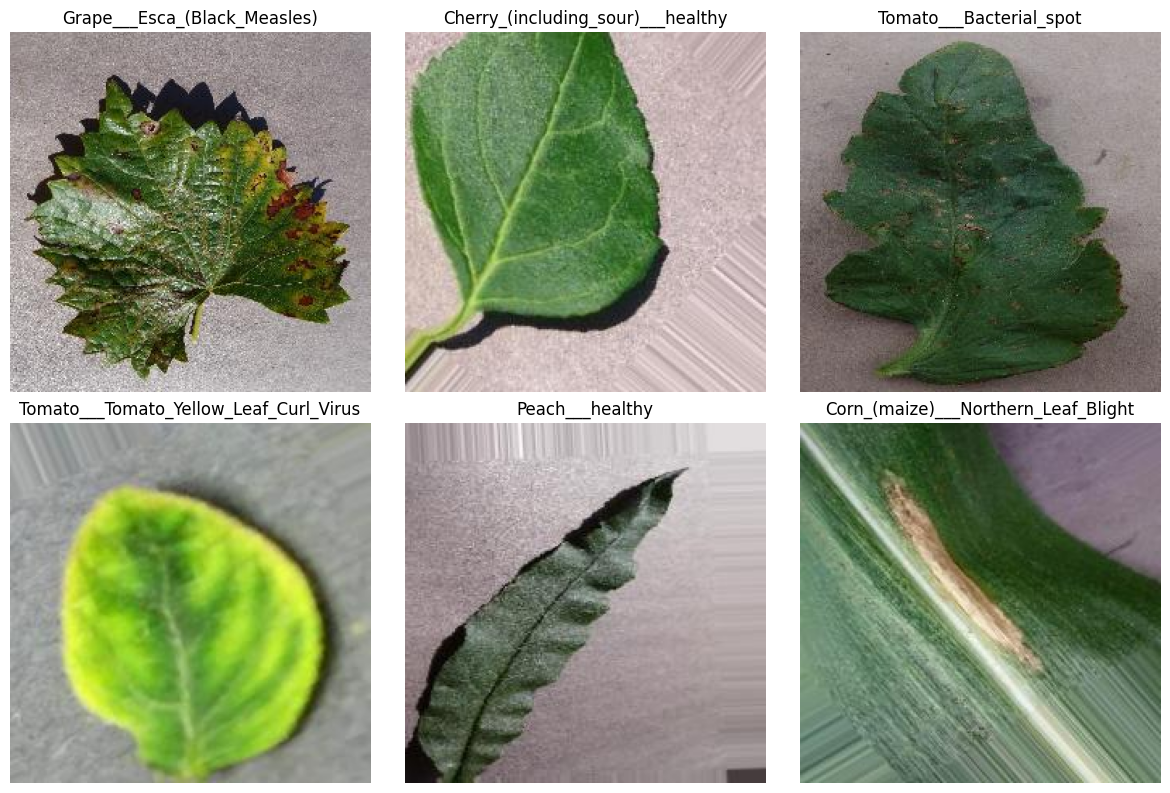

In [ ]:
train_folder = Path("../dataset/train")

classes = [c for c in train_folder.iterdir() if c.is_dir()]

plt.figure(figsize=(12, 8))

num_images = 6  
for i in range(num_images):
    plt.subplot(2, 3, i+1)
    
 
    class_folder = random.choice(classes)
    images = list(class_folder.glob("*.jpg"))
    img_path = random.choice(images)
    
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_folder.name)
    plt.axis('off')

plt.tight_layout()
plt.show()


#### Class Weights

In [ ]:
class_labels = np.unique(train_data['labels'])

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=train_data['labels']
)

# creating dictionary for model.fit()
class_weights = dict(zip(class_labels, class_weights_values))

print(" Class Weights calculated for training:")
for label, weight in class_weights.items():
    print(f"{label:40s} : {weight:.3f}")

 Class Weights calculated for training:
Apple___Apple_scab                       : 2.268
Apple___Black_rot                        : 2.300
Apple___Cedar_apple_rust                 : 5.197
Apple___healthy                          : 0.869
Blueberry___healthy                      : 0.951
Cherry_(including_sour)___Powdery_mildew : 1.358
Cherry_(including_sour)___healthy        : 1.674
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 2.788
Corn_(maize)___Common_rust_              : 1.200
Corn_(maize)___Northern_Leaf_Blight      : 1.451
Corn_(maize)___healthy                   : 1.229
Grape___Black_rot                        : 1.211
Grape___Esca_(Black_Measles)             : 1.034
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1.328
Grape___healthy                          : 3.382
Orange___Haunglongbing_(Citrus_greening) : 0.260
Peach___Bacterial_spot                   : 0.622
Peach___healthy                          : 3.970
Pepper,_bell___Bacterial_spot            : 1.433
Pepper,_bell___he

### baseline pipeline

In [71]:
num_classes = len(train_gen.class_indices)

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(image_size, image_size, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])


model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,979,590 (22.81 MB)

 Trainable params: 5,979,590 (22.81 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
epochs = 3 

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=epochs,
    verbose=1
)


Epoch 1/3
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1485s 546ms/step - accuracy: 0.4564 - loss: 1.9351 - val_accuracy: 0.6064 - val_loss: 1.3221
Epoch 2/3
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1050s 387ms/step - accuracy: 0.6325 - loss: 1.2086 - val_accuracy: 0.7131 - val_loss: 0.9473
Epoch 3/3
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 518s 191ms/step - accuracy: 0.6946 - loss: 0.9801 - val_accuracy: 0.7335 - val_loss: 0.8764


In [73]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")


170/170 ━━━━━━━━━━━━━━━━━━━━ 72s 426ms/step - accuracy: 0.7404 - loss: 0.8536
Test Accuracy: 0.7404
